In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import matplotlib.pyplot as plt


class Passenger:

    def __init__(self, passenger_id, arrival_time):

        self.id = passenger_id
        self.arrival_time = arrival_time

        self.queue_entry_time = None
        self.service_start_time = None
        self.completion_time = None

        self.waiting_time = None


class AirportSecurityModel:

    def __init__(
        self,
        arrival_rate=0.4,
        queue_capacity=10,
        num_checkpoints=2,
        processing_time=3,
        simulation_steps=500
    ):

        self.arrival_rate = arrival_rate
        self.queue_capacity = queue_capacity

        self.num_checkpoints = num_checkpoints
        self.processing_time = processing_time
        self.simulation_steps = simulation_steps

        self.queues = [
            [] for _ in range(num_checkpoints)
        ]

        self.in_service = [
            None for _ in range(num_checkpoints)
        ]

        self.remaining_service_time = [
            0 for _ in range(num_checkpoints)
        ]

        self.external_waiting = []

        self.completed_passengers = []
        self.all_passengers = []

        self.next_passenger_id = 0

        self.queue_length_history = []
        self.external_waiting_history = []


    def create_passenger(self, current_time):

        if np.random.random() < self.arrival_rate:

            passenger = Passenger(
                self.next_passenger_id,
                current_time
            )

            self.next_passenger_id += 1

            self.all_passengers.append(passenger)

            self.assign_queue(
                passenger,
                current_time
            )


    def assign_queue(self, passenger, current_time):

        # One FIFO admission list prevents newcomers overtaking outside waiters.
        self.external_waiting.append(passenger)
        self.move_external_passengers(current_time)


    def move_external_passengers(self, current_time):

        while self.external_waiting:

            available_queues = [
                i for i, queue in enumerate(self.queues)
                if len(queue) < self.queue_capacity
            ]

            if not available_queues:
                break

            # Prefer an idle checkpoint; otherwise choose the shortest queue.
            # The checkpoint index breaks ties deterministically.
            selected = min(
                available_queues,
                key=lambda i: (
                    self.in_service[i] is not None,
                    len(self.queues[i]),
                    i
                )
            )

            passenger = self.external_waiting.pop(0)
            passenger.queue_entry_time = current_time
            self.queues[selected].append(passenger)

            # Start immediately so the next allocation sees updated availability.
            self.start_service(selected, current_time)


    def start_service(
        self,
        checkpoint_id,
        current_time
    ):

        if (
            self.in_service[checkpoint_id] is None
            and len(self.queues[checkpoint_id]) > 0
        ):

            passenger = self.queues[
                checkpoint_id
            ].pop(0)

            passenger.service_start_time = (
                current_time
            )

            passenger.waiting_time = (
                current_time
                - passenger.arrival_time
            )

            self.in_service[
                checkpoint_id
            ] = passenger

            self.remaining_service_time[
                checkpoint_id
            ] = self.processing_time


    def process_checkpoints(
        self,
        current_time
    ):

        for i in range(self.num_checkpoints):

            if self.in_service[i] is not None:

                self.remaining_service_time[i] -= 1

                if (
                    self.remaining_service_time[i]
                    <= 0
                ):

                    passenger = self.in_service[i]

                    passenger.completion_time = (
                        current_time
                    )

                    self.completed_passengers.append(
                        passenger
                    )

                    self.in_service[i] = None

            if self.in_service[i] is None:

                self.start_service(
                    i,
                    current_time
                )


    def record_statistics(self):

        total_queue_length = sum(
            len(queue)
            for queue in self.queues
        )

        self.queue_length_history.append(
            total_queue_length
        )

        self.external_waiting_history.append(
            len(self.external_waiting)
        )


    def run(self):

        for t in range(self.simulation_steps):

            # Finish one step of existing service and serve internal queues first.
            self.process_checkpoints(t)

            # Outside waiters take newly available places before new arrivals.
            self.move_external_passengers(t)

            # New services start at t and are first advanced at t + 1.
            self.create_passenger(t)

            # Record system statistics
            self.record_statistics()


    def get_results(self):

        waiting_times = [
            p.waiting_time
            for p in self.completed_passengers
            if p.waiting_time is not None
        ]

        if waiting_times:

            average_waiting_time = np.mean(
                waiting_times
            )

            maximum_waiting_time = np.max(
                waiting_times
            )

        else:

            average_waiting_time = 0
            maximum_waiting_time = 0

        average_queue_length = np.mean(
            self.queue_length_history
        )

        maximum_queue_length = np.max(
            self.queue_length_history
        )

        throughput = len(
            self.completed_passengers
        )

        external_waiting = len(
            self.external_waiting
        )

        return {
            "average_waiting_time":
                average_waiting_time,

            "maximum_waiting_time":
                maximum_waiting_time,

            "average_queue_length":
                average_queue_length,

            "maximum_queue_length":
                maximum_queue_length,

            "throughput":
                throughput,

            "external_waiting":
                external_waiting
        }
    

In [4]:
model = AirportSecurityModel(
    arrival_rate=0.4,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=3,
    simulation_steps=500
)

model.run()

results = model.get_results()

print(results)

{'average_waiting_time': np.float64(0.35148514851485146), 'maximum_waiting_time': np.int64(3), 'average_queue_length': np.float64(0.162), 'maximum_queue_length': np.int64(3), 'throughput': 202, 'external_waiting': 0}


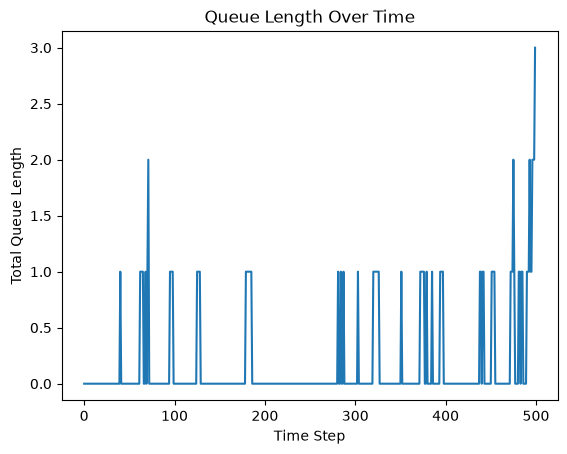

In [5]:
plt.plot(model.queue_length_history)

plt.xlabel("Time Step")
plt.ylabel("Total Queue Length")
plt.title("Queue Length Over Time")

plt.show()

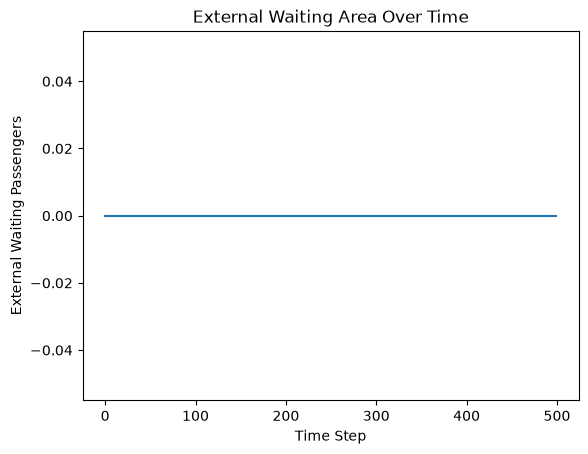

In [6]:
plt.plot(model.external_waiting_history)

plt.xlabel("Time Step")
plt.ylabel("External Waiting Passengers")
plt.title("External Waiting Area Over Time")

plt.show()

In [7]:
low_model = AirportSecurityModel(
    arrival_rate=0.1,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=3,
    simulation_steps=500
)

low_model.run()

print("Low arrival rate:")
print(low_model.get_results())

Low arrival rate:
{'average_waiting_time': np.float64(0.0), 'maximum_waiting_time': np.int64(0), 'average_queue_length': np.float64(0.0), 'maximum_queue_length': np.int64(0), 'throughput': 52, 'external_waiting': 0}


In [8]:
high_model = AirportSecurityModel(
    arrival_rate=0.9,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=3,
    simulation_steps=500
)

high_model.run()

print("High arrival rate:")
print(high_model.get_results())

High arrival rate:
{'average_waiting_time': np.float64(63.36555891238671), 'maximum_waiting_time': np.int64(128), 'average_queue_length': np.float64(18.06), 'maximum_queue_length': np.int64(20), 'throughput': 331, 'external_waiting': 93}
